In [7]:
# ----- ALGORITMO GENETICO-----
import numpy as np 
import matplotlib.pyplot as plt 



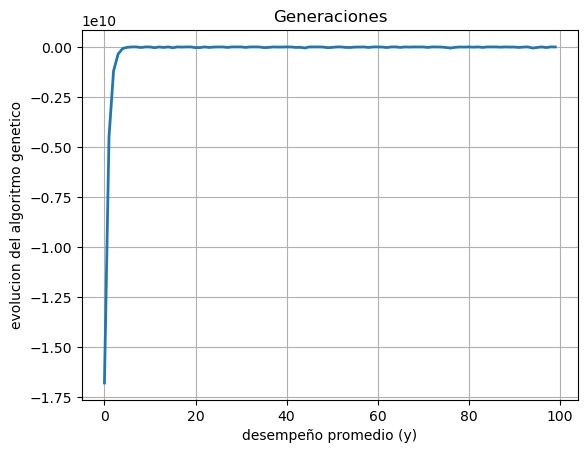

Resultado: x=31.034482758620697, y=98.1815


In [11]:
#-------- inicializacion de la poblacion -------

# definicion de limites y tamaño de paso

xmin = -100 # limite inferior
xmax = 100 # limite superior
tpaso = 0.01 # tamaño de paso


# calculo de elemento y numero de bits

elementos = (xmax-xmin)/tpaso+1 # numero de elementos
nbits = int(np.ceil(np.log2(elementos))) # numero de bits
num_poblacion = 512 # tamaño de poblacion


# padres enteros a padres reales
# generar poblacion inicial de enteros

x1 = np.random.randint(0, 2**nbits, num_poblacion)


# transformar de enteros a reales

x1real = (xmax-xmin)*x1 / (2*nbits-1) + xmin


# matriz para almacenar el promedio del desempeño

yprom = np.zeros(100) # zeros crea una matriz de puros 0


#------- iniciar numero de generaciones -------

for i in range(100):

    # evaluar los padres de la funcion objetivo

    y = -(x1real-41.125)**2 + 200 # funcion de fitness
    yprom[i] = np.mean(y)


    # ordenar los cromosomas (de menor a mayor desempeño)

    indices_ordenados = np.argsort(y)
    x1_ordenado = x1[indices_ordenados]
    x1real_ordenado = x1real[indices_ordenados]


    # seleccionar la mitad (los mejores)

    mejores_x1 = x1_ordenado[num_poblacion//2:]
    mejores_x1real = x1real_ordenado[num_poblacion//2:]

    # convertir padres enteros seleccionados a binario

    padresbin = np.zeros((num_poblacion//2, nbits), dtype=int)

    for idx, val in enumerate(mejores_x1):
        for j in range(nbits):
            padresbin[idx, j] = (int(val) >> j) & 1


    #-------- cruzamiento-----

    hijobin = np.zeros_like(padresbin)

    for k in range(num_poblacion//4):

        # elegir el punto de cruzamiento

        n = np.random.randint(1, nbits-1)

        padre1 = padresbin[2*k]
        padre2 = padresbin[2*k+1]

        # intercambiar informacion para crear hijos binarios

        hijobin[2*k] = np.concatenate((padre1[:n], padre2[n:]))
        hijobin[2*k+1] = np.concatenate((padre2[:n], padre1[n:]))


        #-------- mutacion--------

        p = np.random.rand() # definimos un numero aleatorio entre 0 y 1

        if p > 0.90: # condicion para mutacion (10%)

            # seleccionar aleatoriamente una posicion y un bit

            nhijo = np.random.randint(0, num_poblacion//2)
            nbit = np.random.randint(0, nbits)


            # invertir el valor del bit

            hijobin[nhijo, nbit] = 1 - hijobin[nhijo, nbit]


        # ---- reiniciar proceso (decodificacion)----

        # convertir hijo binario a entero

        hijoent = np.zeros(num_poblacion//2)

        for idx in range(num_poblacion//2):

            val = 0

            for j in range(nbits):
                val += hijobin[idx, j] * (2**j)

            hijoent[idx] = val


        # convertir hijo entero a real usando la funcion de conversacion

        hijoreal = (xmax-xmin)*hijoent/(2*nbits-1) + xmin


        # actualizar matrices pasandolo de hijo a padre

        x1 = np.concatenate((mejores_x1, hijoent))
        x1real = np.concatenate((mejores_x1real, hijoreal))


#------- mostrar resultado en pantalla ------

plt.plot(yprom, linewidth=2)

plt.title("Generaciones")
plt.xlabel("desempeño promedio (y)")
plt.ylabel("evolucion del algoritmo genetico")

plt.grid(True)
plt.show()


# evaluar la funcion final para encontrar el maximo

y = -(x1real-41.125)**2 + 200

val = np.max(y)
ind = np.argmax(y)

print(f"Resultado: x={x1real[ind]}, y={val:.4f}")

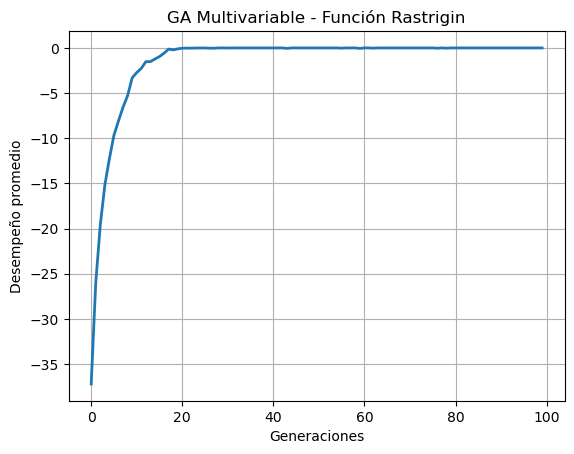

Results: x1= -0.0025 x2= 0.0025 y= -0.0025


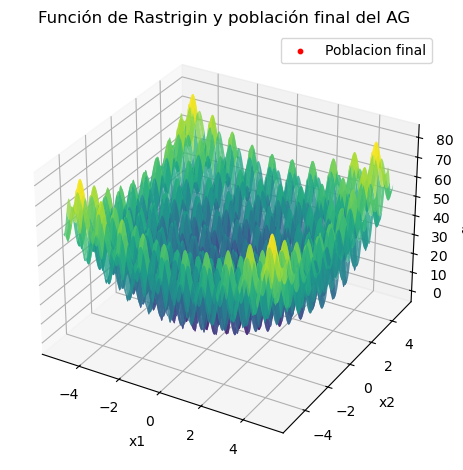

In [13]:
import numpy as np
import matplotlib.pyplot as plt

#-------- inicializacion de la poblacion -------
# ---- limites y bits variable 1 (x1) ----
xmin1 = -5.12
xmax1 = 5.12
tpaso1 = 0.01
elementos1 = (xmax1-xmin1)/tpaso1+1
nbits1 = int(np.ceil(np.log2(elementos1)))

# ---- limites y bits variable 2 (x2) ----
xmin2 = -5.12
xmax2 = 5.12
tpaso2 = 0.01
elementos2 = (xmax2-xmin2)/tpaso2+1
nbits2 = int(np.ceil(np.log2(elementos2)))

num_poblacion = 512 # tamaño de poblacion

# poblacion inicial de enteros
x1 = np.random.randint(0, 2**nbits1, num_poblacion)
x2 = np.random.randint(0, 2**nbits2, num_poblacion)

# transformar de enteros a reales
x1real = (xmax1-xmin1)*x1 / (2**nbits1-1) + xmin1
x2real = (xmax2-xmin2)*x2 / (2**nbits2-1) + xmin2

# matriz para almacenar el promedio del desempeño
num_generaciones = 100
yprom = np.zeros(num_generaciones)

#------- iniciar numero de generaciones -------
for i in range(num_generaciones):
    # evaluar los padres con la funcion de Rastrigin (minimizamos -> se usa -y como fitness a maximizar)
    y = -(20 + x1real**2 + x2real**2 - 10*np.cos(2*np.pi*x1real) - 10*np.cos(2*np.pi*x2real))
    yprom[i] = np.mean(y)

    # ordenar los cromosomas (de menor a mayor desempeño)
    indices_ordenados = np.argsort(y)
    x1_ordenado = x1[indices_ordenados]
    x1real_ordenado = x1real[indices_ordenados]
    x2_ordenado = x2[indices_ordenados]
    x2real_ordenado = x2real[indices_ordenados]

    # seleccionar la mitad (los mejores)
    mejores_x1 = x1_ordenado[num_poblacion//2:]
    mejores_x1real = x1real_ordenado[num_poblacion//2:]
    mejores_x2 = x2_ordenado[num_poblacion//2:]
    mejores_x2real = x2real_ordenado[num_poblacion//2:]

    # convertir padres enteros seleccionados a binario (x1)
    padresbin1 = np.zeros((num_poblacion//2, nbits1), dtype=int)
    for idx, val in enumerate(mejores_x1):
        for j in range(nbits1):
            padresbin1[idx, j] = (int(val) >> j) & 1

    # convertir padres enteros seleccionados a binario (x2)
    padresbin2 = np.zeros((num_poblacion//2, nbits2), dtype=int)
    for idx, val in enumerate(mejores_x2):
        for j in range(nbits2):
            padresbin2[idx, j] = (int(val) >> j) & 1

    #-------- cruzamiento-----
    hijobin1 = np.zeros_like(padresbin1)
    hijobin2 = np.zeros_like(padresbin2)
    for k in range(num_poblacion//4):
        # cruzamiento x1
        n1 = np.random.randint(1, nbits1-1)
        padre1a = padresbin1[2*k]
        padre1b = padresbin1[2*k+1]
        hijobin1[2*k] = np.concatenate((padre1a[:n1], padre1b[n1:]))
        hijobin1[2*k+1] = np.concatenate((padre1b[:n1], padre1a[n1:]))

        # cruzamiento x2
        n2 = np.random.randint(1, nbits2-1)
        padre2a = padresbin2[2*k]
        padre2b = padresbin2[2*k+1]
        hijobin2[2*k] = np.concatenate((padre2a[:n2], padre2b[n2:]))
        hijobin2[2*k+1] = np.concatenate((padre2b[:n2], padre2a[n2:]))

    #-------- mutacion (una vez por generacion, independiente por variable) --------
    # Mutación variable 1
    if np.random.rand() > 0.90:
        nhijo = np.random.randint(0, num_poblacion // 2)
        bit = np.random.randint(0, nbits1)
        hijobin1[nhijo, bit] = 1 - hijobin1[nhijo, bit]

    # Mutación variable 2
    if np.random.rand() > 0.90:
        nhijo = np.random.randint(0, num_poblacion // 2)
        bit = np.random.randint(0, nbits2)
        hijobin2[nhijo, bit] = 1 - hijobin2[nhijo, bit]

    # --------- Reiniciar proceso (Decodificación) ---------
    hijoent1 = np.zeros(num_poblacion // 2)
    hijoent2 = np.zeros(num_poblacion // 2)

    for idx in range(num_poblacion // 2):
        val1 = val2 = 0
        for j in range(nbits1):
            val1 += hijobin1[idx, j] * (2 ** j)
        for j in range(nbits2):
            val2 += hijobin2[idx, j] * (2 ** j)
        hijoent1[idx], hijoent2[idx] = val1, val2

    hijoreal1 = (xmax1 - xmin1) * hijoent1 / (2**nbits1 - 1) + xmin1
    hijoreal2 = (xmax2 - xmin2) * hijoent2 / (2**nbits2 - 1) + xmin2

    # Actualizar matrices
    x1 = np.concatenate((mejores_x1, hijoent1))
    x1real = np.concatenate((mejores_x1real, hijoreal1))
    x2 = np.concatenate((mejores_x2, hijoent2))
    x2real = np.concatenate((mejores_x2real, hijoreal2))

# --------- Mostrar resultado ---------
plt.plot(yprom, linewidth=2)
plt.xlabel("Generaciones")
plt.ylabel("Desempeño promedio")
plt.title("GA Multivariable - Función Rastrigin")
plt.grid(True)
plt.show()

# Evaluar función final y encontrar máximo (equivalente al mínimo de Rastrigin)
y = -(20 + x1real**2 + x2real**2 - 10*np.cos(2*np.pi*x1real) - 10*np.cos(2*np.pi*x2real))
val = np.max(y)
ind = np.argmax(y)

print(f"Results: x1= {x1real[ind]:.4f} x2= {x2real[ind]:.4f} y= {val:.4f}")

# --------- Grafica 3D de la funcion de Rastrigin y poblacion final ---------
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

xg = np.linspace(xmin1, xmax1, 200)
yg = np.linspace(xmin2, xmax2, 200)
Xg, Yg = np.meshgrid(xg, yg)
Zg = 20 + Xg**2 + Yg**2 - 10*np.cos(2*np.pi*Xg) - 10*np.cos(2*np.pi*Yg)

ax.plot_surface(Xg, Yg, Zg, cmap='viridis', alpha=0.8)
zpoblacion = 20 + x1real**2 + x2real**2 - 10*np.cos(2*np.pi*x1real) - 10*np.cos(2*np.pi*x2real)
ax.scatter(x1real, x2real, zpoblacion, color='red', s=10, label="Poblacion final")

ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('f(x1,x2)')
ax.set_title('Función de Rastrigin y población final del AG')
ax.legend()
plt.tight_layout()
plt.show()